In [1]:
# Cell 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [2]:
# Cell 2
df = pd.read_csv("heart.csv")   # change file name if needed
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
# Cell 3
X = df.drop("target", axis=1)   # features
y = df["target"]                # label

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
# Cell 4
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [5]:
# Cell 5
y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9853658536585366


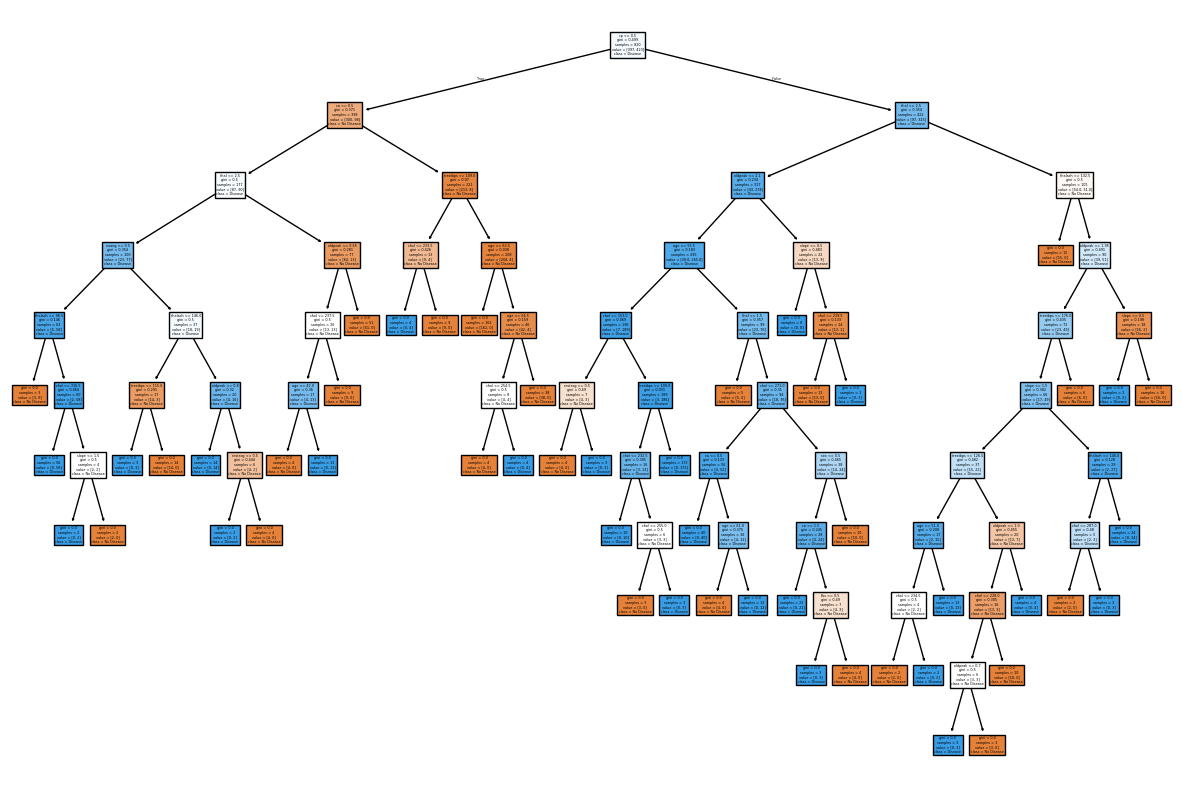

In [6]:
# Cell 6
plt.figure(figsize=(15,10))
plot_tree(dt_model, feature_names=X.columns, class_names=["No Disease", "Disease"], filled=True)
plt.show()

In [7]:
# Cell 7
dt_limited = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_limited.fit(X_train, y_train)

y_pred_limited = dt_limited.predict(X_test)

print("Limited Depth Accuracy:", accuracy_score(y_test, y_pred_limited))

Limited Depth Accuracy: 0.7804878048780488


In [8]:
# Cell 8
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [9]:
# Cell 9
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.9853658536585366


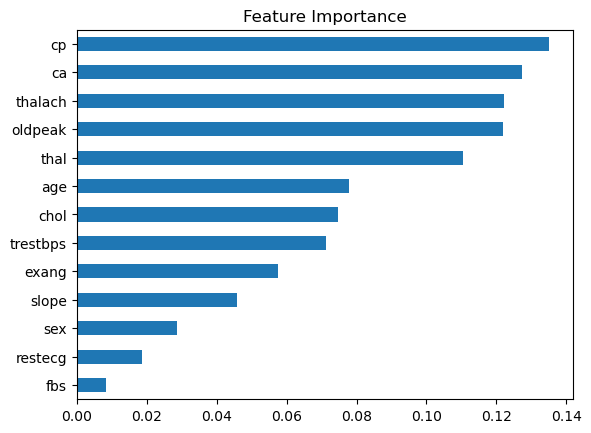

In [10]:
# Cell 10
importances = rf_model.feature_importances_

feat_imp = pd.Series(importances, index=X.columns)
feat_imp.sort_values().plot(kind='barh')

plt.title("Feature Importance")
plt.show()

In [11]:
# Cell 11
cv_scores = cross_val_score(rf_model, X, y, cv=5)

print("Cross Validation Scores:", cv_scores)
print("Average CV Score:", np.mean(cv_scores))

Cross Validation Scores: [1.         1.         1.         1.         0.98536585]
Average CV Score: 0.9970731707317073
